In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
from Preprocess import preprocess_data
from sklearn.linear_model import LinearRegression
from numpy.polynomial.polynomial import polyfit 
from sklearn.utils import resample 
import scipy 
from scipy.signal import detrend

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known,  = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)


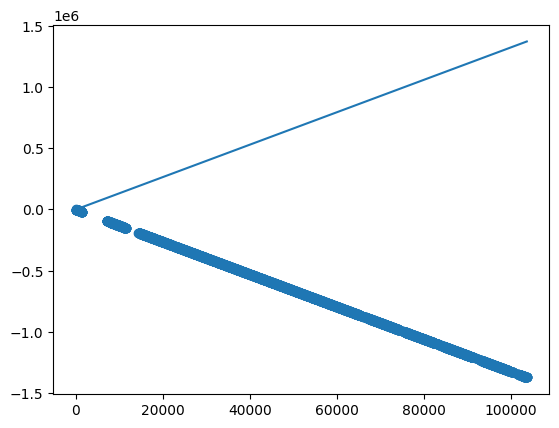

In [ ]:
'''#print(data_orig.head())
plt.figure()

x= pd.to_datetime(data_orig["start_time"])
x=(x-x.min()).dt.total_seconds() / 3600

x=x.to_numpy()
#plt.scatter(x,filtered_time["time_to_next_ev_hr"])
m , b = polyfit(x,filtered_time["time_to_next_ev_hr"],1)
#filtered_time["time_to_next_ev_hr"] = (filtered_time["time_to_next_ev_hr"] -b)/m +b 
trend = np.polyval([m,b], x)
filtered_time["time_to_next_ev_hr"] = filtered_time["time_to_next_ev_hr"] - trend +b 
filtered_time.to_csv("detrended.csv")
plt.scatter(x,filtered_time["time_to_next_ev_hr"])
plt.plot(x, b + m * x, '-')
#plt.plot([min(X_train["TTNS"]), max(X_train["TTNS"])], [min(X_train["TTNS"]), max(X_train["TTNS"])])
#plt.xlabel("True TTNS (s)")
#plt.ylabel("Predicted TTNS (s)")
#plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()'''

In [9]:
'''X_train_bs, y_train_bs = resample(X_train, y_train, n_samples=4000, random_state=42)
X_train_bs[:20]
y_train_bs[:20]'''

'X_train_bs, y_train_bs = resample(X_train, y_train, n_samples=4000, random_state=42)\nX_train_bs[:20]\ny_train_bs[:20]'

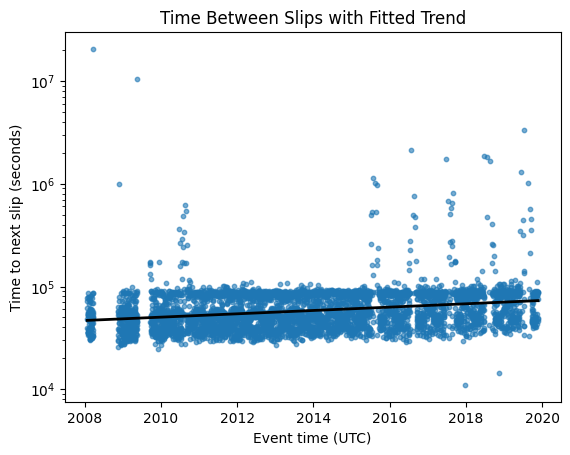

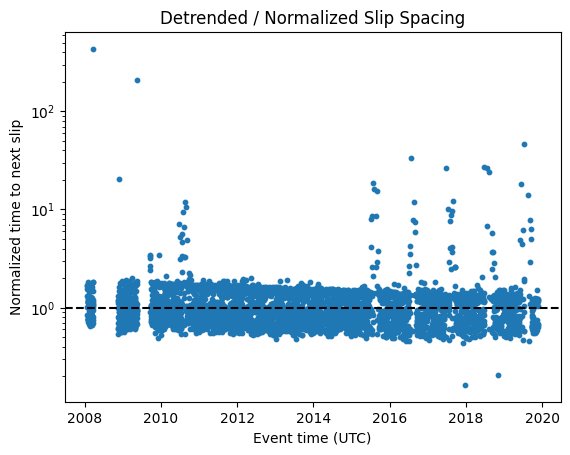

Saved: filtered_time_normalized.csv
   Unnamed: 0          ev_time_utc  time_to_next_ev_hr
0           0  2008-01-25 01:50:00            1.323515
1           1  2008-01-25 19:11:15            1.668045
2           2  2008-01-26 16:57:15            0.833945
3           3  2008-01-27 03:42:45            1.020927
4           4  2008-01-27 16:58:00            1.537068


In [ ]:
# Detrend/Normalize for testing whether the change in amount of second slips over time has an effect 

# Making the time stamps a date-time object and finding the difference time betweene each slip event 
data_orig["start_time"] = pd.to_datetime(data_orig["start_time"])
data_orig = data_orig.sort_values("start_time")

data_orig["time_to_next_sec"] = (
    data_orig["start_time"].shift(-1) - data_orig["start_time"]
).dt.total_seconds()

# Drop invalid values like the last row 
df = data_orig.dropna(subset=["time_to_next_sec"])
df = df[df["time_to_next_sec"] > 0]

# Getting the numeric values from the dataset 
time = df["start_time"].iloc[0]
df["t_sec"] = (df["start_time"] - time).dt.total_seconds()

# Getting the line of best fit (in log for better fit)
log_y = np.log(df["time_to_next_sec"])
coeffs = np.polyfit(df["t_sec"], log_y, 1)

# Looking at the trend in log-space and linear space
df["log_trend"] = np.polyval(coeffs, df["t_sec"])
df["trend_sec"] = np.exp(df["log_trend"])

# Detrending 
df["normalized_gap"] = df["time_to_next_sec"] / df["trend_sec"]

# Plot of orig 
plt.figure()
plt.scatter(df["start_time"], df["time_to_next_sec"], s=10, alpha=0.6)
plt.plot(df["start_time"], df["trend_sec"], color="black", linewidth=2)
plt.yscale("log")
plt.xlabel("Event time (UTC)")
plt.ylabel("Time to next slip (seconds)")
plt.title("Time Between Slips with Fitted Trend")
plt.show()

# Plot of normalized 
plt.figure()
plt.scatter(df["start_time"], df["normalized_gap"], s=10)
plt.axhline(1.0, color="black", linestyle="--")
plt.xlabel("Event time (UTC)")
plt.ylabel("Normalized time to next slip")
plt.yscale("log")
plt.title("Detrended / Normalized Slip Spacing")
plt.show()

# Putting in CSV to run through ML models 
norm = filtered_time.copy()
norm = norm.loc[df.index].copy()
norm["time_to_next_ev_hr"] = df["normalized_gap"].values
norm.to_csv("filtered_time_normalized.csv",index=True)
print(norm.head())